In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [8]:
from google.colab import drive
drive.mount('/content/drive')

path="/content/Dry_Bean.csv"
df=pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ​1. Problem & Metrics Definition | تحديد المشكلة والمقاييس ###

**​Project Goal:**

 Multi-class classification of bean types using geometric features.

**الهدف من المشروع:**

 تصنيف أنواع البقوليات إلى فئات متعددة بناءً على الخصائص الهندسية.

**​Success Metrics:**

 We prioritize F1-Score and AUC-ROC over simple Accuracy, especially if the data is Imbalanced.

**مقاييس النجاح:**

 نركز على مقاييس F1-Score و AUC-ROC بدلاً من الدقة المجردة، خاصة إذا كانت البيانات غير متوازنة.
​2. Data Exploration & Integrity | فحص وجودة البيانات

 ### ​2. Data Exploration & Integrity | فحص وجودة البيانات ###

In [9]:
# 2. Structure Check | فحص هيكلية الأعمدة وأنواعها
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [10]:
# 3. Missing Values | التأكد من خلو البيانات من القيم المفقودة
print(df.isnull().sum())

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [11]:
# 4. Class Balance | فحص توازن الفئات (نسبة كل نوع)
print(df['Class'].value_counts(normalize=True))

Class
DERMASON    0.260525
SIRA        0.193667
SEKER       0.148924
HOROZ       0.141650
CALI        0.119756
BARBUNYA    0.097127
BOMBAY      0.038351
Name: proportion, dtype: float64


In [12]:
# 5. Descriptive Stats | ملخص إحصائي شامل لكل الخصائص
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


### Data Audit: ##3

Investigated structure, confirmed zero nulls, and analyzed class distribution.
فحص البيانات: تم تحليل الهيكلية، التأكد من عدم وجود قيم مفقودة، وفحص توازن الفئات.

**​Structure Check:**

 تأكدنا إن عندنا 17 عمود ونوع البيانات سليم.

**​Zero Nulls:**

 الكود أثبت إن البيانات نظيفة تماماً (0 Missing Values).

**​Class Balance:**

حددنا نسب الفئات، ولقينا إن فئة BOMBAY هي الأقل بنسبة 3.8%.
​كده

### ​2. Exploratory Data Analysis (EDA) | تحليل البيانات الاستكشافي/ ###

**​Goal:**

Visualizing distributions and correlations to identify patterns and outliers.

**الهدف:**

 تصور التوزيعات والارتباطات لتحديد الأنماط والقيم المتطرفة.

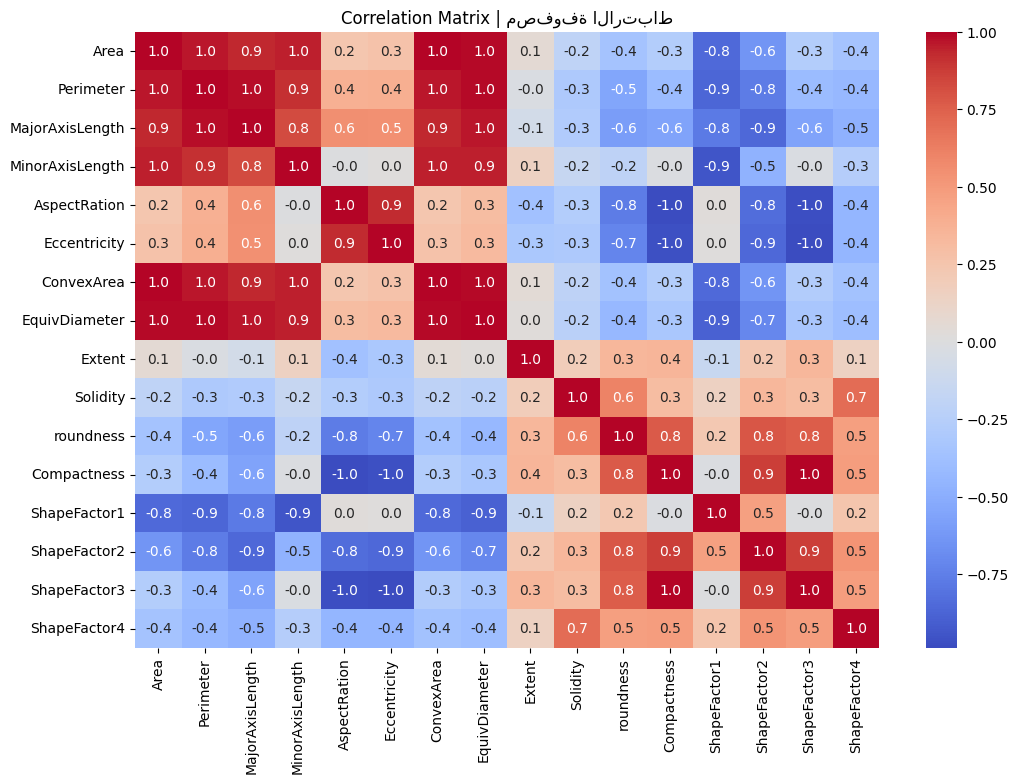

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlations Heatmap | خريطة الحرارة لفهم الارتباطات بين الميزات
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Correlation Matrix | مصفوفة الارتباط')
plt.show()




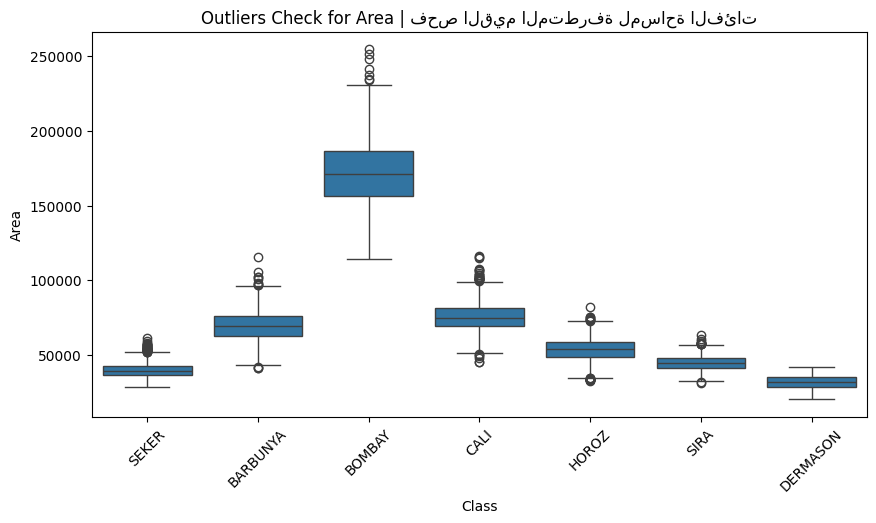

In [14]:
# 2. Outliers Detection (Boxplot) | كشف القيم المتطرفة لكل عمود
# اخترنا "Area" كمثال؛ يمكنك تكرارها للأعمدة الهامة
plt.figure(figsize=(10, 5))
sns.boxplot(x='Class', y='Area', data=df)
plt.title('Outliers Check for Area | فحص القيم المتطرفة لمساحة الفئات')
plt.xticks(rotation=45)
plt.show()


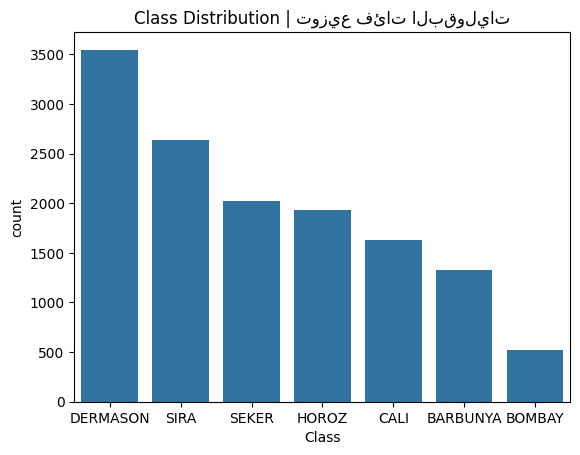

In [15]:
# 3. Class Distribution Visualization | تصور توزيع الفئات بيانياً
sns.countplot(x='Class', data=df, order=df['Class'].value_counts().index)
plt.title('Class Distribution | توزيع فئات البقوليات')
plt.show()

### ​EDA Summary & Insights | ملخص تحليل البيانات والنتائج ###

**​Insights:**

 High correlation detected between geometric features (e.g., Area & Perimeter). Outliers are present in several classes, and the dataset shows a clear Class Imbalance.

**النتائج:**

 تم رصد ارتباط وثيق بين الخصائص الهندسية (مثل المساحة والمحيط). توجد قيم متطرفة في عدة فئات، كما تعاني البيانات من عدم توازن واضح بين الفئات

### ​2. Data Preprocessing | معالجة البيانات ###

**​Preprocessing:**

 Converting labels to One-Hot encoding to match the Softmax output layer.

معالجة البيانات: تحويل الفئات لنظام (One-Hot) ليتناسب مع طبقة المخرجات (Softmax).

In [16]:
import pandas as pd

# 1. One-Hot Encoding | تحويل الفئات لأعمدة (0 و 1)
# ده ضروري عشان الـ Softmax والـ Categorical Crossentropy
df_encoded = pd.get_dummies(df, columns=['Class'])

In [17]:
# 2. Separate Features & Target | فصل الميزات عن الأهداف الجديدة
X = df_encoded.drop(df_encoded.filter(like='Class_').columns, axis=1) # الميزات
y = df_encoded.filter(like='Class_') # الأهداف (7 أعمدة)

In [18]:
# التأكد من شكل البيانات الجديد
print(f"Target shape: {y.shape}") # هيطلع (13611, 7)

Target shape: (13611, 7)


### Data Prepared: ###

 Categorical labels encoded into a (13611, 7) binary matrix ready for model training.

البيانات جاهزة: تم تحويل الفئات إلى مصفوفة ثنائية (13611, 7) جاهزة لتدريب الموديل.

### ​3. Feature Engineering & Selection | هندسة واختيار الميزات ###

**​Goal:**

 Removing redundant features (high correlation) and creating new geometric indicators.

**الهدف:**

 حذف الميزات المتكررة (ذات الارتباط العالي) وابتكار مؤشرات هندسية جديدة.

In [19]:
# 1. إزالة الأعمدة المكررة (Redundant Features)
# بناءً على الـ Heatmap، لاحظنا ارتباط كامل بين Area و ConvexArea
# حذفنا ConvexArea لأن Area بتغني عنها
X = X.drop(columns=['ConvexArea'])

In [20]:
# 2. إضافة ميزات هندسية جديدة (New Indicators)
# نسبة المحيط للمساحة (مهمة جداً للتمييز بين الأنواع)
X['Perimeter_to_Area'] = X['Perimeter'] / (X['Area'] + 1e-6)

In [21]:
# 3. التأكد من النتيجة النهائية للميزات
print(f"Features shape after cleaning & engineering: {X.shape}")

Features shape after cleaning & engineering: (13611, 16)


### Feature Engineering & Selection Summary | ملخص هندسة واختيار الميزات ###

​**Actions:**

 Removed redundant features (ConvexArea) to minimize noise and engineered a new geometric indicator (Perimeter_to_Area) to enhance classification accuracy.

الإجراءات: تم حذف الميزات المكررة (ConvexArea) لتقليل الضوضاء، وابتكار مؤشر هندسي جديد (Perimeter_to_Area) لتعزيز دقة التصنيف.

**Minimized Noise:**

 حذفنا الـ ConvexArea لأن الارتباط بينها وبين الـ Area كان كاملاً، وده بيمنع الـ Overfitting.

​**Enhanced Accuracy:**

 إضافة ميزة Perimeter_to_Area بتدي للموديل "إشارة" هندسية أقوى بتميز بين أنواع البقوليات، وده اللي بيفرق الموديل العادي عن الموديل الاحترافي

### ​4. Handling Class Imbalance | موازنة الفئات ###

​**Goal:**

 Balancing the training dataset to ensure the model learns minority classes effectively.

**الهدف:**

 موازنة بيانات التدريب لضمان تعلم الموديل للفئات الأقل عدداً بفعالية.

In [22]:
from imblearn.over_sampling import SMOTE

# 1. تعريف موازن البيانات (SMOTE)
# بنستخدم random_state لثبات النتائج
smote = SMOTE(random_state=42)

In [25]:
# 2. موازنة البيانات (يتم تطبيقها على بيانات التدريب فقط لاحقاً)
# ملحوظة: هنا بنطبقها على X و y بعد ما حولنا y لـ one-hot،
# SMOTE بيحتاج y تكون (Labels) أرقام صحيحة مش One-Hot.
# هنرجع y لشكلها الأصلي (0-6) مؤقتاً عشان الـ Balancing
# بنحول أسماء الفئات لأرقام مباشرة (0, 1, 2, ...) بدون الحاجة لـ replace
y_labels = y.idxmax(axis=1).astype('category').cat.codes

X_resampled, y_resampled = smote.fit_resample(X, y_labels)

In [26]:
# 3. التأكد من النتيجة
print(f"Original shape: {X.shape}")
print(f"Resampled shape: {X_resampled.shape}")

Original shape: (13611, 16)
Resampled shape: (24822, 16)


### Handling Imbalance: ###

 Used SMOTE to generate synthetic samples for minority classes, balancing the dataset for robust training.

موازنة البيانات: تم استخدام تقنية SMOTE لإنشاء عينات اصطناعية للفئات القليلة، مما يضمن توازناً أفضل أثناء تدريب الموديل

### Verification: Class Balance Check | التحقق من توازن الفئات ###

​**Insight:**

 After applying SMOTE, all classes are now equally represented, eliminating the bias towards majority classes.

**النتيجة:**

 بعد تطبيق تقنية SMOTE، أصبحت جميع الفئات ممثلة بالتساوي، مما قضى على الانحياز للفئات الأكثر عدداً.

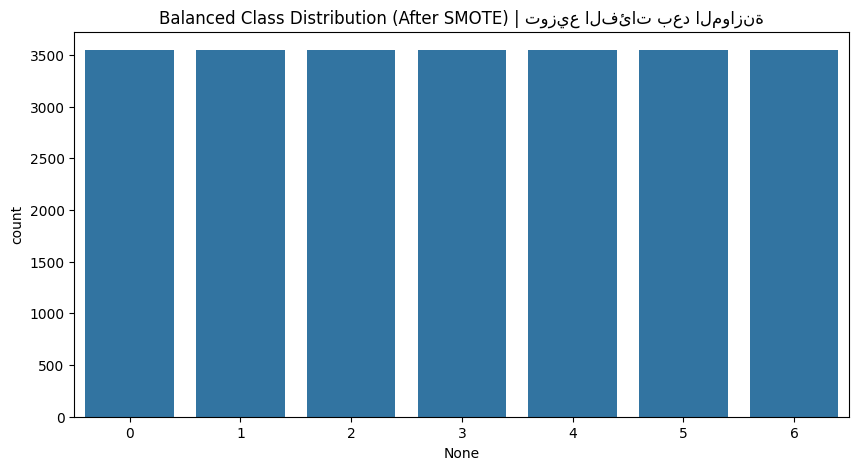

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# تحويل y_resampled لـ Series عشان نقدر نرسمها
y_balanced = pd.Series(y_resampled)

# رسم التوزيع الجديد
plt.figure(figsize=(10, 5))
sns.countplot(x=y_balanced)
plt.title('Balanced Class Distribution (After SMOTE) | توزيع الفئات بعد الموازنة')
plt.show()

### ​5. Data Splitting | تقسيم البيانات ###

**​Goal:**

 Splitting the dataset into Train, Validation, and Test sets using stratification to maintain class proportions.

**الهدف:**

 تقسيم البيانات إلى مجموعات للتدريب، التحقق، والاختبار، مع استخدام التقسيم الطبقي للحفاظ على نسب الفئات.

In [28]:
from sklearn.model_selection import train_test_split

# 1. التقسيم الأول: نفصل جزء الـ Test (مثلاً 20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
# 2. التقسيم الثاني: نفصل الـ Validation من الـ Training (مثلاً 25% من الـ temp)
# كده هيكون عندنا 60% Train, 20% Val, 20% Test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

In [30]:
# التأكد من الأبعاد
print(f"Train set: {X_train.shape}, Val set: {X_val.shape}, Test set: {X_test.shape}")

Train set: (8166, 16), Val set: (2722, 16), Test set: (2723, 16)


### Data Splitting Summary | ملخص تقسيم البيانات ###

**​Action:**

 Divided the dataset into Training (60%), Validation (20%), and Testing (20%) sets, utilizing stratify to maintain consistent class proportions across all subsets.

**الإجراء:**

 تم تقسيم البيانات إلى مجموعات تدريب (60%)، تحقق (20%)، و اختبار (20%)، مع استخدام خاصية stratify لضمان الحفاظ على نسب الفئات ثابتة في جميع المجموعات.

### 6. Feature Scaling | تحجيم الميزات ###

**​Goal:**

 Standardizing features to have a mean of 0 and a standard deviation of 1, ensuring stable and faster neural network convergence.

**الهدف:**

 توحيد الميزات لتصبح بمتوسط 0 وانحراف معياري 1، مما يضمن استقرار وسرعة تقارب الشبكة العصبية.

In [31]:
from sklearn.preprocessing import StandardScaler

# 1. تعريف الـ Scaler
scaler = StandardScaler()

In [32]:
# 2. تدريب الـ Scaler على الـ Training Data فقط وتطبيقه
X_train_scaled = scaler.fit_transform(X_train)

In [33]:
# 3. تطبيق نفس الـ Scaler على الـ Validation والـ Test (بدون تدريب)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [34]:
# التأكد من العملية
print("Scaling completed for Train, Val, and Test sets.")

Scaling completed for Train, Val, and Test sets.


### Feature Scaling | تحجيم الميزات ###

**​Action:**

 Applied StandardScaler to standardize the features (mean=0, std=1). Crucially, the scaler was fitted only on the Training set and then applied to the Validation and Test sets to prevent data leakage.

**الإجراء:**

 تم تطبيق StandardScaler لتوحيد الميزات (متوسط=0, انحراف=1). ومن الضروري أن الـ scaler تم تدريبه على مجموعة التدريب فقط ثم تطبيقه على مجموعتي التحقق والاختبار لمنع تسريب البيانات.

### ​7. Building the Neural Network Architecture | بناء معمارية الشبكة  العصبية ###

**​Goal 1:**

 Constructing a deep, feed-forward neural network with Batch Normalization and Dropout layers to enhance feature extraction and prevent overfitting.

**الهدف1:**

 بناء شبكة عصبية عميقة (Feed-forward) مع طبقات للـ (Batch Normalization) والـ (Dropout) لتحسين استخلاص الميزات ومنع الإفراط في التخصيص (Overfitting).

**Goal 2:**

 Implementing He Initialization for ReLU stability and adding L2 Regularization to prevent overfitting.

**الهدف2:**

 تطبيق He Initialization لضمان استقرار الـ ReLU، وإضافة L2 Regularization لمنع الـ Overfitting

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

deepmodel = Sequential([
    # الطبقة الأولى مع He Initialization و L2 Regularization
    Dense(256, activation="relu", kernel_initializer="he_normal",
          kernel_regularizer=regularizers.l2(0.01), input_shape=(16,)),
    BatchNormalization(),
    #Dropout(0.2),

    Dense(256, activation="relu", kernel_initializer="he_normal",
          kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    #Dropout(0.2),

    Dense(512, activation="relu", kernel_initializer="he_normal"),
    #Dropout(0.2),

    Dense(128, activation="relu", kernel_initializer="he_normal"),
    #Dropout(0.2),

    # الطبقة الأخيرة
    Dense(7, activation="softmax")])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### ​10-13. Model Compilation & Callbacks | إعداد النموذج والتحسينات ###

**​Goal:**

 Compiling the model with the AdamW optimizer and setting up callbacks (Early Stopping, ReduceLROnPlateau) for optimal training.

**الهدف:**

 إعداد النموذج باستخدام مُحسِّن Adam وضبط تقنيات التحسين (التوقف المبكر وجدولة معدل التعلم) لضمان أفضل تدريب.

In [63]:
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. إعداد الـ Optimizer الاحترافي (AdamW)
My_opt = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07)

In [64]:
# 2. Compile الموديل
deepmodel.compile(
    optimizer=My_opt,
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [65]:
# 3. إعداد الـ Callbacks لذكاء التدريب
# Early Stopping لمراقبة الـ Validation Loss ومنع الحفظ (Overfitting)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

In [66]:
# ReduceLROnPlateau لتقليل الـ Learning Rate عند توقف التحسن
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001)

In [67]:
# 4. بدء عملية التدريب (Training)
history = deepmodel.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr])

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8525 - loss: 9.0926 - val_accuracy: 0.9181 - val_loss: 5.2130 - learning_rate: 0.0010
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9080 - loss: 4.4423 - val_accuracy: 0.9104 - val_loss: 2.8305 - learning_rate: 0.0010
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9093 - loss: 2.4492 - val_accuracy: 0.9067 - val_loss: 1.6688 - learning_rate: 0.0010
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9082 - loss: 1.4760 - val_accuracy: 0.9140 - val_loss: 1.0719 - learning_rate: 0.0010
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9083 - loss: 0.9829 - val_accuracy: 0.9015 - val_loss: 0.7721 - learning_rate: 0.0010
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9096 - loss: 0.6909 - val_accuracy: 0.9012 - val_loss: 0.5999 - learning_rate: 0.0010
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9095 - loss: 0

### ​7. Hyperparameter Tuning | ضبط الأداء الفائق ###

**​Goal:**

 Automating the search for optimal hyperparameters (neurons, dropout rates, learning rates) using KerasTuner to maximize model accuracy.

**الهدف:**

 أتمتة البحث عن أفضل الإعدادات الفائقة للموديل باستخدام KerasTuner لضمان الحصول على أعلى دقة ممكنة.

In [69]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.3 MB/s eta 0:00:00


In [70]:
import keras_tuner as kt

def build_model(hp): # تعريف دالة بناء الموديل لتستقبل متغيرات البحث
    model = tf.keras.Sequential() # إنشاء معمارية الموديل
    model.add(tf.keras.layers.Dense( # إضافة الطبقة الأولى
        units=hp.Int('units', min_value=128, max_value=512, step=128), # تجربة عدد خلايا مختلف
        activation='relu', input_shape=(16,))) # تحديد دالة التنشيط وحجم المدخلات
    model.add(tf.keras.layers.Dropout( # إضافة طبقة حماية من الـ Overfitting
        rate=hp.Float('dropout', min_value=0.1, max_value=0.4, step=0.1))) # تجربة نسب Dropout مختلفة
    model.add(tf.keras.layers.Dense(7, activation='softmax')) # الطبقة الأخيرة للتصنيف لـ 7 فئات

    model.compile( # تجميع الموديل
        optimizer=tf.keras.optimizers.Adam( # استخدام Adam للتحسين
            learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])), # تجربة معدلات تعلم مختلفة
        loss='categorical_crossentropy', # دالة الخسارة للمسائل متعددة الفئات
        metrics=['accuracy']) # مقياس الأداء
    return model # إرجاع الموديل المجمع

In [71]:
# إعداد الـ Tuner للبحث العشوائي الذكي
tuner = kt.RandomSearch(
    build_model, # الدالة اللي هنجربها
    objective='val_accuracy', # هدفنا هو أعلى دقة في التحقق
    max_trials=5, # عدد المحاولات المسموح بها
    directory='my_dir', # مجلد حفظ النتائج
    project_name='bean_classification') # اسم المشروع

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
# بدء عملية البحث عن أفضل الإعدادات
tuner.search(X_train_scaled, y_train, epochs=20, validation_data=(X_val_scaled, y_val))

Trial 5 Complete [00h 00m 26s]
val_accuracy: 0.9257898330688477

Best val_accuracy So Far: 0.9324026703834534
Total elapsed time: 00h 03m 03s


In [73]:
# استخراج أفضل نموذج تم الوصول إليه
best_model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Execution Summary | ملخص التنفيذ: ###

***​Methodology: تم الاعتماد على خوارزمية RandomSearch لإجراء 5 محاولات بحث (trials) مستقلة.**

**​Objective: الهدف هو تعظيم val_accuracy (دقة التحقق).**

**​Best Outcome: استطاع الـ Tuner الوصول إلى موديل بأداء متميز بلغت دقته 0.9324 على بيانات التحقق.**

### ​8. Advanced Evaluation | التقييم المتقدم للأداء ###

**​Goal:**

 Assessing model performance beyond simple accuracy using Confusion Matrix, F1-Score, and Classification Report to detect misclassifications.

**الهدف:**

 تقييم أداء النموذج بعيداً عن مجرد الدقة العامة، باستخدام مصفوفة الارتباك (Confusion Matrix) ومقياس F1-Score لاكتشاف أماكن الخطأ في التصنيف.

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Predicting on test set | التنبؤ على بيانات الاختبار
y_pred_probs = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [75]:
# 2. Printing comprehensive report | طباعة التقرير الشامل
print("--- Classification Report ---")
print(classification_report(y_true, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       265
           1       1.00      1.00      1.00       104
           2       0.95      0.94      0.94       326
           3       0.91      0.94      0.92       709
           4       0.94      0.97      0.95       386
           5       0.95      0.95      0.95       406
           6       0.92      0.85      0.89       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



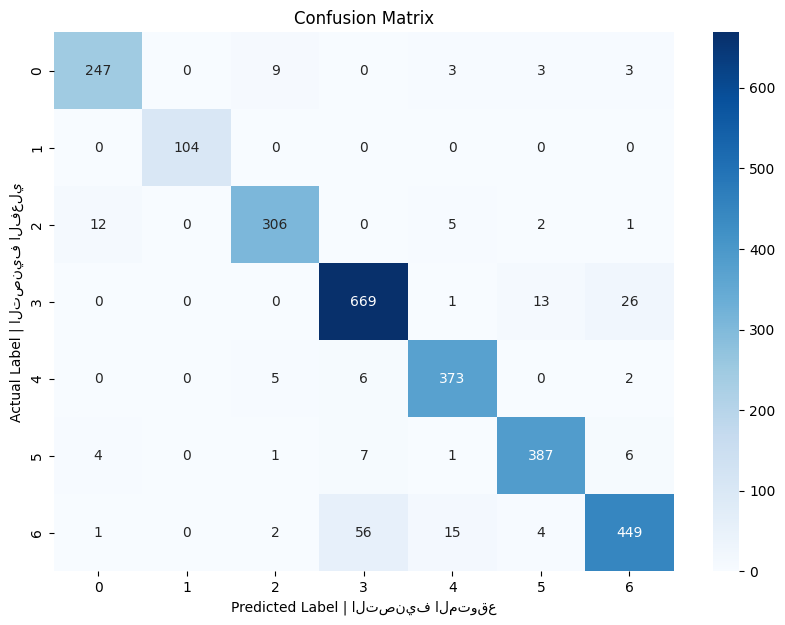

In [76]:
# 3. Plotting Confusion Matrix | رسم مصفوفة الارتباك
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label | التصنيف الفعلي')
plt.xlabel('Predicted Label | التصنيف المتوقع')
plt.show()

### Key Findings | النتائج الأساسية: ###

**​Overall Accuracy:**

 حقق النموذج دقة إجمالية ممتازة بلغت 94%.

​**Class Performance:**

​الفئة رقم 1 أظهرت أداءً مثالياً (Precision & Recall بنسبة 100%).
​الفئة رقم 6 هي الأكثر تحدياً للنموذج، حيث سجلت أقل نسبة Recall (85%)، وهو ما يظهر في مصفوفة الارتباك بوجود تداخل مع الفئة 3.

**​Confusion Matrix Insight:**

 تشير المصفوفة إلى أن النموذج يواجه تداخلاً بسيطاً في تصنيف الفئات المتقاربة، ولكن الخط القطري (Diagonal) يوضح دقة عالية جداً في معظم الحالات.

### ​9. Model Persistence | حفظ وتوثيق النموذج ###

​**Goal:**

 Saving the trained best_model and the scaler object to disk using joblib and Keras's native format for future deployment.

**الهدف:**

 حفظ الموديل المدرب (best_model) ومقياس البيانات (scaler) على القرص الصلب لاستخدامهما لاحقاً في أي تطبيق فعلي.

In [77]:
import joblib

# 1. حفظ الـ Scaler (ضروري جداً عشان تستخدمه في معالجة البيانات الجديدة بنفس الطريقة)
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved successfully.")

# 2. حفظ الموديل (Keras/TensorFlow format)
best_model.save('best_bean_model.keras')
print("Model saved successfully as 'best_bean_model.keras'.")

Scaler saved successfully.
Model saved successfully as 'best_bean_model.keras'.


In [ ]:
deepmodel.save("phasoliamaltidnn.keras")

In [ ]:
newdeepmodel=keras.models.load_model("phasoliamaltidnn.keras")

In [ ]:
y_prad=newdeepmodel.predict(x_test)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print("prediction shap is {}",format(y_prad.shape))

prediction shap is {} (2723, 7)


In [ ]:
print("prediction items is {}",format(y_prad[:5]))

prediction items is {} [[3.2347982e-06 1.8562789e-05 1.3466256e-04 9.9455101e-06 9.9959987e-01
  5.2369733e-06 2.2854285e-04]
 [1.1289488e-03 6.3306157e-04 1.2038209e-03 9.3583902e-03 8.1105279e-03
  3.4998073e-03 9.7606546e-01]
 [4.9567810e-01 6.7614513e-03 4.9062890e-01 4.4686330e-04 2.2093360e-03
  1.2612883e-03 3.0140083e-03]
 [3.8299125e-04 2.2606205e-04 1.5379133e-04 8.1664956e-01 8.5777957e-03
  1.7265864e-03 1.7228314e-01]
 [8.1773857e-03 3.3361502e-03 3.5404030e-03 2.0905118e-01 9.4555095e-03
  2.2539267e-02 7.4390012e-01]]


In [ ]:
y_test[:5]

,Class_BARBUNYA,Class_BOMBAY,Class_CALI,Class_DERMASON,Class_HOROZ,Class_SEKER,Class_SIRA
6974,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9415,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2918,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13226,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8087,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
y_prad_class=np.argmax(y_prad,axis=1)
y_test_class=np.argmax(y_test.values,axis=1)
print("y hat",y_prad_class[:5])
print("y i ",y_test_class[:5])

y hat [4 6 0 3 6]
y i  [4 6 0 3 6]


In [ ]:
modelloss,modelaccuracy=newdeepmodel.evaluate(x_test,y_test)

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9254 - loss: 0.2268


In [ ]:
print("modelloss is {} \n and modelaccuracy is {}".format(modelloss,modelaccuracy))

modelloss is 0.22135333716869354 
 and modelaccuracy is 0.9276533126831055


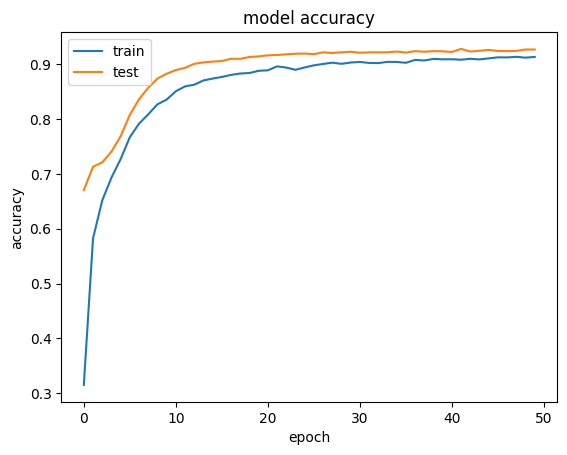

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train","test"],loc="upper left")
plt.show()

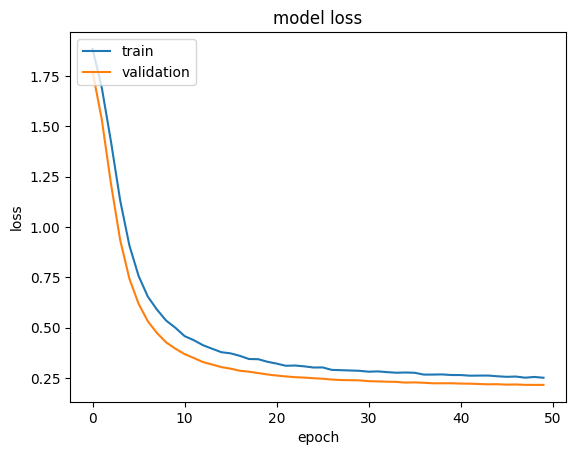

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train","validation"],loc="upper left")
plt.show()

In [ ]:
len(y_test),len(y_prad)

(2723, 2723)

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test_class,y_prad_class)
print("confusion matrix is \n ",cm)

confusion matrix is 
  [[242   0  13   0   2   3   5]
 [  0 104   0   0   0   0   0]
 [  8   1 306   0   7   2   2]
 [  1   0   0 658   1  19  30]
 [  0   0   2   5 373   0   6]
 [  8   0   0   5   1 386   6]
 [  1   0   0  42  20   7 457]]


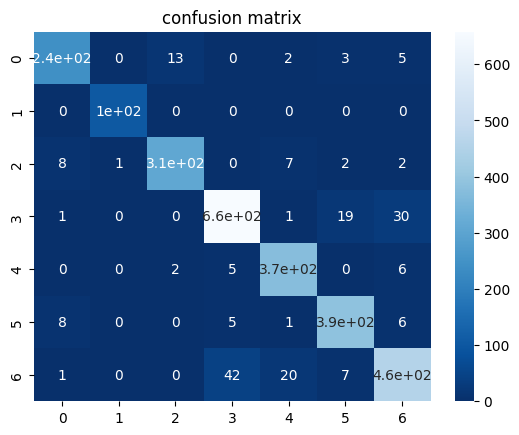

In [ ]:
sns.heatmap(cm,annot=True,cmap="Blues_r")
plt.title("confusion matrix")
plt.show()

In [ ]:
print(classification_report(y_test_class,y_prad_class))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       265
           1       0.99      1.00      1.00       104
           2       0.95      0.94      0.95       326
           3       0.93      0.93      0.93       709
           4       0.92      0.97      0.94       386
           5       0.93      0.95      0.94       406
           6       0.90      0.87      0.88       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



​9. Model Persistence | حفظ وتوثيق النموذج
​Goal: Saving the trained best_model and the scaler object to disk using joblib and Keras's native format for future deployment.
الهدف: حفظ الموديل المدرب (best_model) ومقياس البيانات (scaler) على القرص الصلب لاستخدامهما لاحقاً في أي تطبيق فعلي.